# 1. Import the necessary libraries

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

### 1.1 fetch the dataset from uci

In [36]:
wine = fetch_ucirepo(id=186)

In [37]:
print(wine.variables)

                    name     role         type demographic  \
0          fixed_acidity  Feature   Continuous        None   
1       volatile_acidity  Feature   Continuous        None   
2            citric_acid  Feature   Continuous        None   
3         residual_sugar  Feature   Continuous        None   
4              chlorides  Feature   Continuous        None   
5    free_sulfur_dioxide  Feature   Continuous        None   
6   total_sulfur_dioxide  Feature   Continuous        None   
7                density  Feature   Continuous        None   
8                     pH  Feature   Continuous        None   
9              sulphates  Feature   Continuous        None   
10               alcohol  Feature   Continuous        None   
11               quality   Target      Integer        None   
12                 color    Other  Categorical        None   

               description units missing_values  
0                     None  None             no  
1                     None  Non

### 1.2 Understand the data

In [38]:
print(type(wine))
#since the wine variable is dict, we have to convert it into pandas dataframe

<class 'ucimlrepo.dotdict.dotdict'>


In [39]:
wine_df = wine.data.original.copy()

In [40]:
wine_df.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,color
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [41]:
wine_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   float64
 6   total_sulfur_dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  color                 6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [42]:
wine_df.describe()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [43]:
wine_df.shape

(6497, 13)

# 2. Investigate the data if it has duplicated or null values

In [44]:
cols = wine_df.columns.tolist()
for feature in cols:
    print(f'{feature} null values: {wine_df[feature].isnull().sum()}')
#this shows that no null values in each feature

fixed_acidity null values: 0
volatile_acidity null values: 0
citric_acid null values: 0
residual_sugar null values: 0
chlorides null values: 0
free_sulfur_dioxide null values: 0
total_sulfur_dioxide null values: 0
density null values: 0
pH null values: 0
sulphates null values: 0
alcohol null values: 0
quality null values: 0
color null values: 0


In [45]:
wine_df.duplicated().sum()

np.int64(1177)

In [46]:
#drop the duplicated values
wine_df.drop_duplicates()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,color
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,red
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.99780,3.51,0.56,9.4,5,red
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,white
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,white
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,white
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,white


# 3. Use histograms to visualize the data

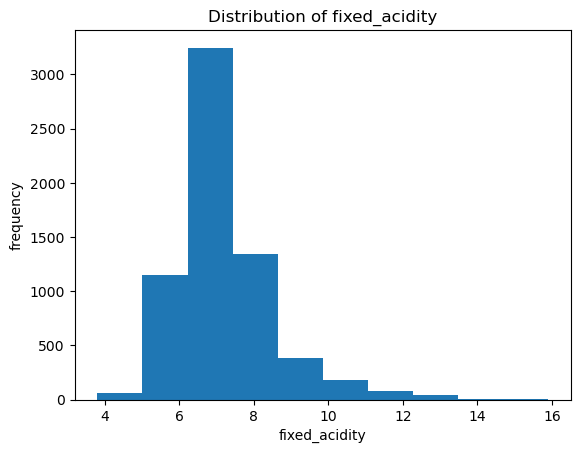

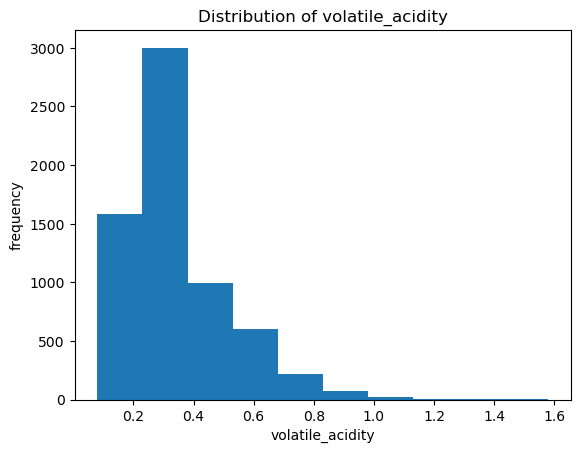

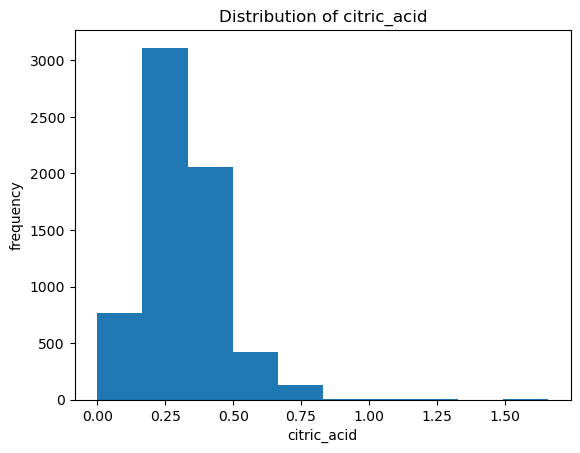

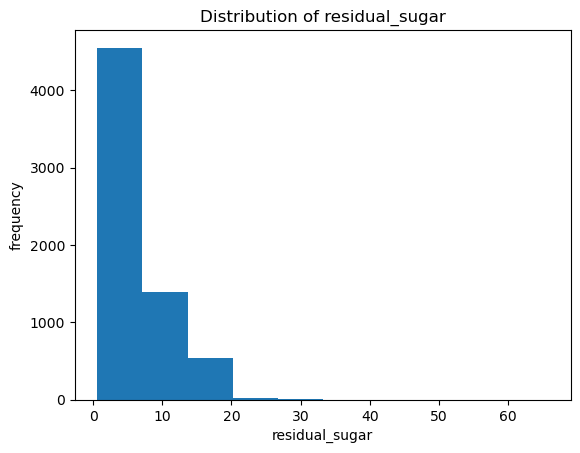

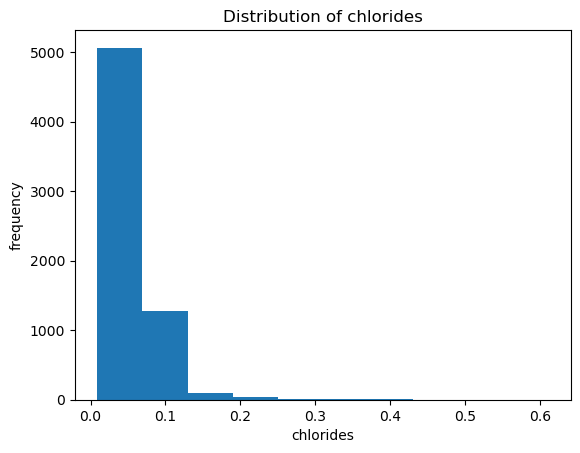

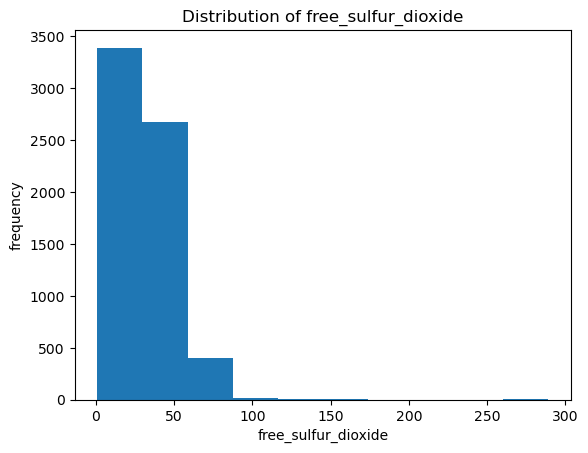

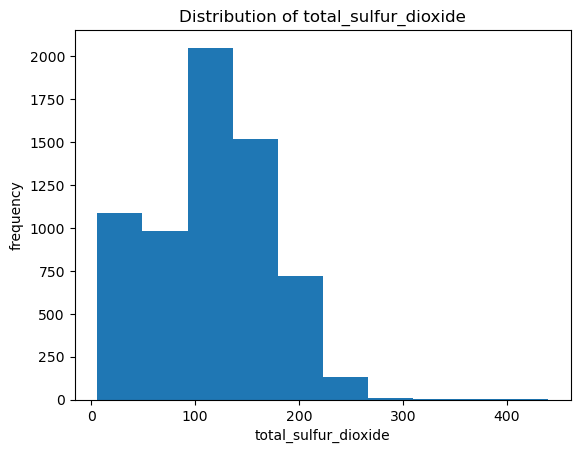

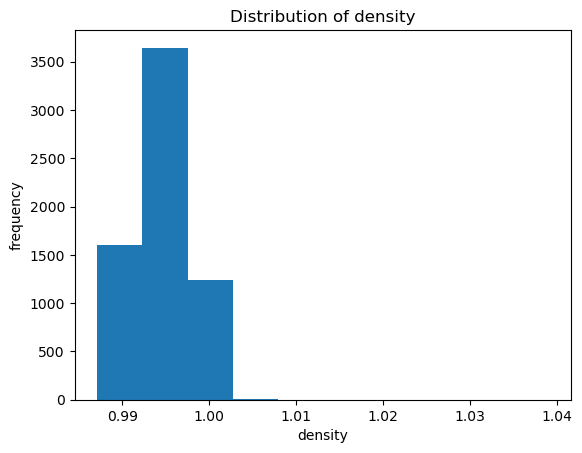

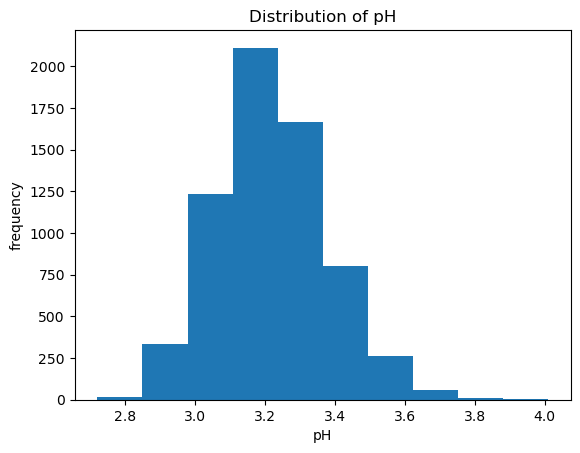

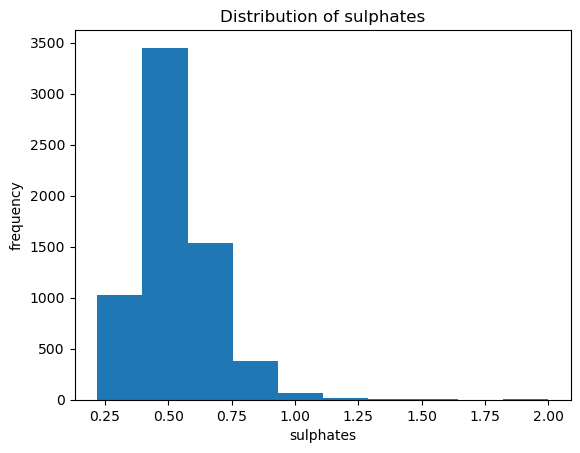

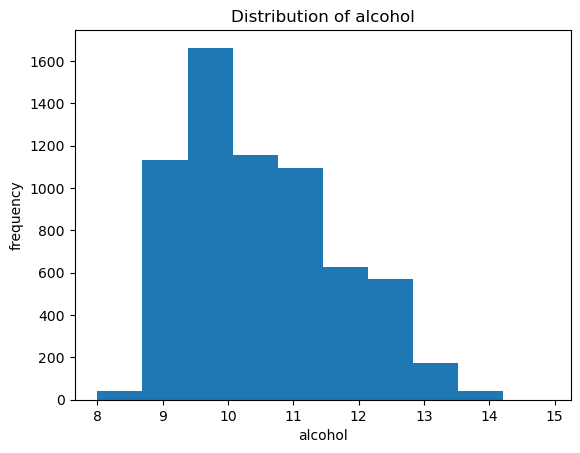

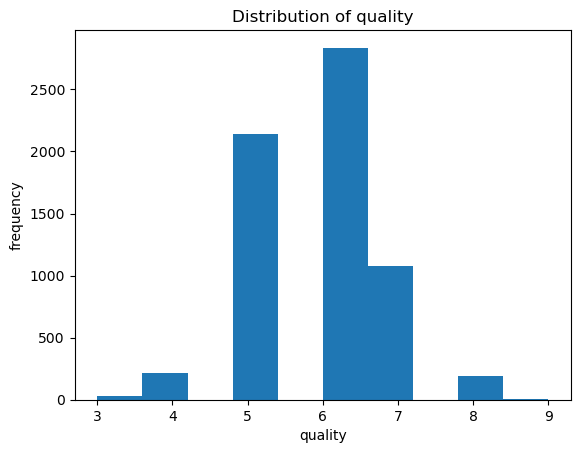

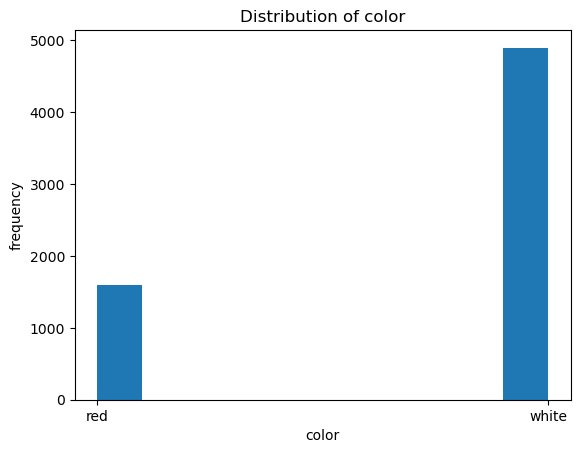

In [52]:
cols = wine_df.columns.tolist()
for feature in cols:
    plt.hist(wine_df[feature])
    plt.xlabel(feature)
    plt.ylabel('frequency')
    plt.title(f'Distribution of {feature}')
    plt.show()

In [53]:
#in this histogram, i noticed that the distribution of free_sulfur_dioxide contains a possible outlier. To verify this we can use boxplot.

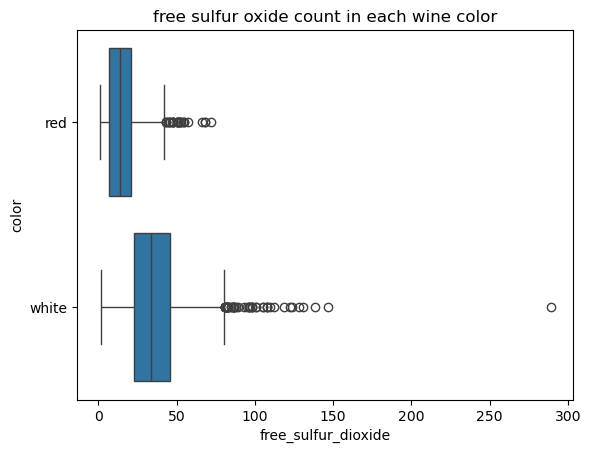

In [54]:
sns.boxplot(x='free_sulfur_dioxide', y='color', data=wine_df)
plt.xlabel('free_sulfur_dioxide')
plt.ylabel('color')
plt.title('free sulfur oxide count in each wine color')
plt.show()

In [61]:
#by this boxplot, we identified that there's a lot of outliers outside the interquartile range. We have to clean it
#for this notebook we will remove the outliers (we can also use winsoration so that no rows will be wasted)

### Collect all the outliers

In [62]:
Q1 = wine_df['free_sulfur_dioxide'].quantile(.25)
Q3 = wine_df['free_sulfur_dioxide'].quantile(.75)
IQR = Q3 - Q1

In [66]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = wine_df[(wine_df['free_sulfur_dioxide'] < lower_bound )|
                    (wine_df['free_sulfur_dioxide'] > upper_bound)]

print(f"Number of outliers: {outliers.shape[0]}")
print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")

Number of outliers: 62
Lower bound: -19.0, Upper bound: 77.0


In [67]:
wine_df_cleaned = wine_df[(wine_df['free_sulfur_dioxide'] >= lower_bound) |
                    (wine_df['free_sulfur_dioxide'] <= upper_bound)]

<Axes: >

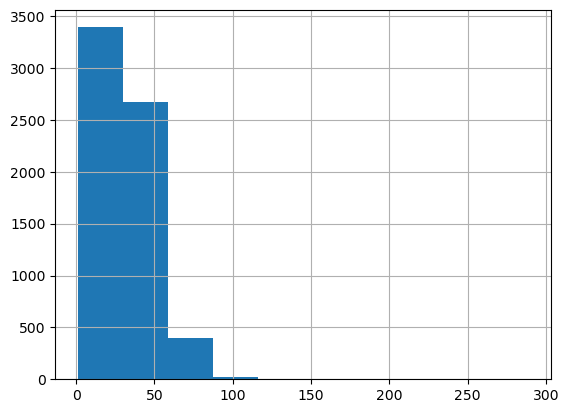

In [68]:
wine_df_cleaned['free_sulfur_dioxide'].hist()

# 4. Label Encode the Color since it has binary value

In [70]:
le = LabelEncoder()
wine_df_cleaned['color'] = le.fit_transform(wine_df_cleaned['color'])

In [71]:
wine_df_cleaned['color']

0       0
1       0
2       0
3       0
4       0
       ..
6492    1
6493    1
6494    1
6495    1
6496    1
Name: color, Length: 6497, dtype: int64

# 5. Use heatmap for correlation

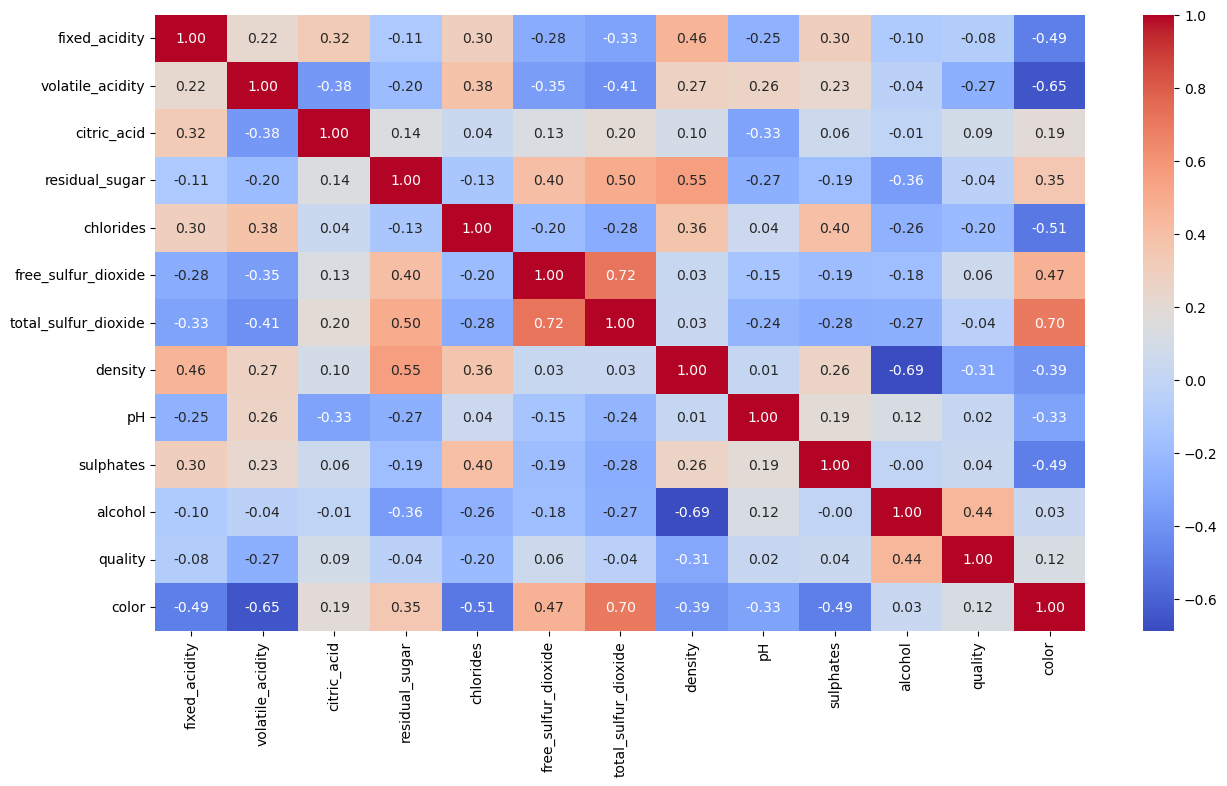

In [73]:
plt.figure(figsize=(15,8))
sns.heatmap(wine_df_cleaned.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()